# 📧 A/B Test Analysis — Email Marketing Campaign

## Scope

We sent two versions of the same email to our users:
- **Group A (Control):** The old email (what we already send)
- **Group B (Treatment):** The new email we want to test

**Questions we want to answer:**
1. Does the new email get more users to click?
2. Does it bring more purchases (conversions)?
3. Does it generate more revenue?
4. Does it cause more users to unsubscribe? (bad!)
5. Is it worth rolling out overall?

---

## Analysis Outline

| Step | What we do |
|------|------------|
| 1 | Load & understand the data |
| 2 | Check the experiment was set up correctly |
| 3 | Calculate key metrics (rates) |
| 4 | Statistical significance — is the difference real or random? |
| 5 | How large is the effect? |
| 6 | Estimate business value |

## Import Libraries

We only import what we actually need:
- **pandas**: data manipulation
- **matplotlib**: charts
- **scipy.stats**: statistical tests

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu

# Show numbers with 4 decimal places by default
pd.options.display.float_format = '{:.4f}'.format

---
## Step 1: Load & Understand the Data

### What does each column mean?

| Column | Meaning | Values |
|--------|---------|--------|
| `user_id` | Unique user ID | Number |
| `group` | Which email version the user received | `control` or `treatment` |
| `opened_email` | Did the user open the email? | 0 = No, 1 = Yes |
| `clicked_email` | Did the user click a link inside the email? | 0 = No, 1 = Yes |
| `converted` | Did the user make a purchase? | 0 = No, 1 = Yes |
| `unsubscribed` | Did the user unsubscribe? | 0 = No, 1 = Yes |
| `revenue` | Revenue generated by the user (£) | 0 if no purchase |

> **Important:** Each row = 1 user. The columns are 0/1 flags, NOT rates.
> We calculate the rates ourselves after aggregating.

In [12]:
# Load the data
df = pd.read_csv('ab_test_email_campaign.csv')

print(f"Total users: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print()

# Show a sample of the data
df.head()

Total users: 10,000
Columns: ['user_id', 'group', 'opened_email', 'clicked_email', 'converted', 'unsubscribed', 'revenue', 'timestamp']



,user_id,group,opened_email,clicked_email,converted,unsubscribed,revenue,timestamp
0,1,control,0,0,0,0,0.0000,2024-01-01 00:00:00
1,2,treatment,0,0,0,0,0.0000,2024-01-01 00:01:00
2,3,control,0,0,0,0,0.0000,2024-01-01 00:02:00
3,4,control,0,0,0,0,0.0000,2024-01-01 00:03:00
4,5,control,1,0,0,0,0.0000,2024-01-01 00:04:00


In [21]:
# Quick overview: data types and missing values
# Knowing your dtypes early prevents silent bugs (e.g. strings treated as numbers)
print("Data types and null counts:")
df.info()

Data types and null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   user_id        10000 non-null  int64  
 1   group          10000 non-null  object 
 2   opened_email   10000 non-null  int64  
 3   clicked_email  10000 non-null  int64  
 4   converted      10000 non-null  int64  
 5   unsubscribed   10000 non-null  int64  
 6   revenue        10000 non-null  float64
 7   timestamp      10000 non-null  object 
dtypes: float64(1), int64(5), object(2)
memory usage: 625.1+ KB


In [22]:
# Basic descriptive statistics
# For 0/1 columns, 'mean' = the proportion of 1s (e.g. open rate across all users)
# For 'revenue', note the high std and max — revenue is right-skewed (a few big orders)
df.describe()

,user_id,opened_email,clicked_email,converted,unsubscribed,revenue
count,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000
mean,5000.5000,0.2706,0.0325,0.0029,0.0295,0.1526
std,2886.8957,0.4443,0.1773,0.0538,0.1692,3.0558
min,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,2500.7500,0.0000,0.0000,0.0000,0.0000,0.0000
50%,5000.5000,0.0000,0.0000,0.0000,0.0000,0.0000
75%,7500.2500,1.0000,0.0000,0.0000,0.0000,0.0000
max,10000.0000,1.0000,1.0000,1.0000,1.0000,89.9801


---
## Exploratory Data Analysis (EDA)

EDA is about **getting to know your data before you run any tests.**  
It helps you spot:
- Unexpected patterns or anomalies
- Whether distributions look sensible
- Early signals of what might be interesting

We look at:
1. Group sizes (is the split even?)
2. Funnel drop-off (how many users reach each stage?)
3. Revenue distribution (is it skewed? are there outliers?)
4. Raw event rates side by side

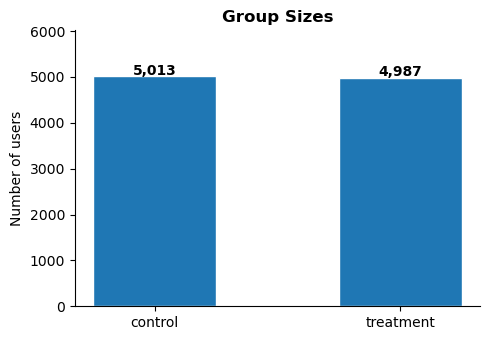

Control:   5,013  (50.1%)
Treatment: 4,987  (49.9%)


In [26]:
# Group sizes
group_counts = df['group'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(group_counts.index, group_counts.values, edgecolor='white', width=0.5)

for bar, val in zip(bars, group_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            f'{val:,}', ha='center', fontweight='bold')

ax.set_title('Group Sizes', fontweight='bold')
ax.set_ylabel('Number of users')
ax.set_ylim(0, group_counts.max() * 1.2)
sns.despine()
plt.tight_layout()
plt.show()

print(f"Control:   {group_counts['control']:,}  ({group_counts['control']/len(df):.1%})")
print(f"Treatment: {group_counts['treatment']:,}  ({group_counts['treatment']/len(df):.1%})")

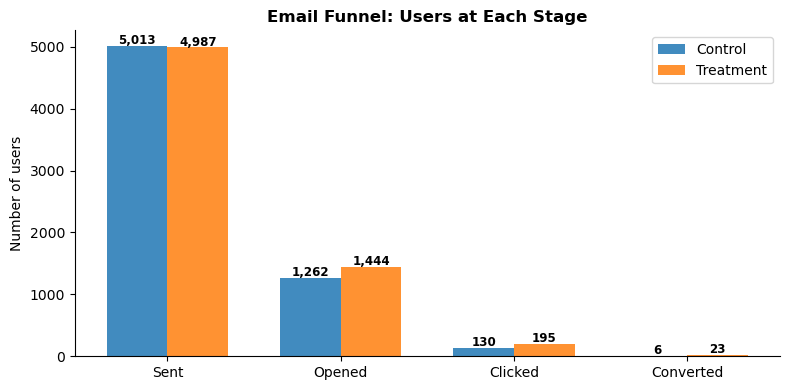

In [32]:
funnel = df.groupby('group')[['opened_email', 'clicked_email', 'converted']].sum()
funnel.insert(0, 'Sent', df['group'].value_counts())
funnel = funnel.T  # stages as rows, groups as columns

fig, ax = plt.subplots(figsize=(8, 4))
x     = range(len(funnel))
width = 0.35

b1 = ax.bar([i - width/2 for i in x], funnel['control'],   width, label='Control', alpha=0.85)
b2 = ax.bar([i + width/2 for i in x], funnel['treatment'], width, label='Treatment', alpha=0.85)

for bar in b1.patches + b2.patches:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            f'{int(bar.get_height()):,}', ha='center', fontsize=8.5, fontweight='bold')

ax.set_xticks(list(x))
ax.set_xticklabels(['Sent', 'Opened', 'Clicked', 'Converted'])
ax.set_title('Email Funnel: Users at Each Stage', fontweight='bold')
ax.set_ylabel('Number of users')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

---
## Experiment Validity Checks

Before looking at results, we need to make sure the experiment was set up correctly.
If these checks fail, the results cannot be trusted.

### What do we check?

**1. Group balance (roughly 50/50 split)**
Both groups should have approximately the same number of users.
If one group is much larger, the comparison is not fair.

**2. Funnel logic (clicks <= opens, conversions <= clicks)**
You cannot click a link in an email you never opened.
You cannot purchase without having clicked.
If this is violated, there is a data quality problem.

In [13]:
# Group balance
group_counts = df['group'].value_counts()
group_pct    = df['group'].value_counts(normalize=True)

print("Group sizes:")
print(f"  Control:   {group_counts['control']:,} users ({group_pct['control']:.1%})")
print(f"  Treatment: {group_counts['treatment']:,} users ({group_pct['treatment']:.1%})")

if abs(group_pct['control'] - 0.5) < 0.02:
    print("  Groups are balanced -- OK")
else:
    print("  WARNING: Groups are imbalanced -- investigate!")

print()

# Check Funnel logic
print("Funnel logic check:")
clicks_without_open = (df['clicked_email'] > df['opened_email']).sum()
conv_without_click  = (df['converted'] > df['clicked_email']).sum()

print(f"  Clicks without an open: {clicks_without_open} (should be 0)")
print(f"  Conversions without a click: {conv_without_click} (should be 0)")

if clicks_without_open == 0 and conv_without_click == 0:
    print("  Funnel logic is intact -- OK")

Group sizes:
  Control:   5,013 users (50.1%)
  Treatment: 4,987 users (49.9%)
  Groups are balanced -- OK

Funnel logic check:
  Clicks without an open: 0 (should be 0)
  Conversions without a click: 0 (should be 0)
  Funnel logic is intact -- OK


---
## Calculate Metrics (KPIs)

### Which metrics do we track?

| Metric | Formula | What it tells us |
|--------|---------|------------------|
| **Open Rate** | opens / total users | How many users opened the email |
| **CTR** (Click-Through Rate) | clicks / opens | Of those who opened, how many clicked |
| **Conversion Rate** | conversions / clicks | Of those who clicked, how many purchased |
| **Unsubscribe Rate** | unsubs / total users | How many left our list (guard-rail metric) |
| **Revenue / User** | total revenue / total users | Average revenue generated per user |

> **Guard-rail metric:** A metric we do NOT want to increase.
> Even if conversions go up, if unsubscribes spike too much it may not be worth the trade-off
> because we permanently lose future marketing reach to those users.

In [14]:
# Split the data into the two groups for convenience
ctrl = df[df['group'] == 'control']
trt  = df[df['group'] == 'treatment']


def calc_metrics(group_df):
    """Calculates all key KPIs for a given group DataFrame."""
    n           = len(group_df)
    opens       = group_df['opened_email'].sum()
    clicks      = group_df['clicked_email'].sum()
    conversions = group_df['converted'].sum()
    unsubs      = group_df['unsubscribed'].sum()
    revenue     = group_df['revenue'].sum()

    return {
        'Users':                n,
        'Open Rate':            opens / n,
        'CTR (clicks / opens)': clicks / opens if opens > 0 else 0,
        'Conversion Rate':      conversions / clicks if clicks > 0 else 0,
        'Unsubscribe Rate':     unsubs / n,
        'Revenue / User':       revenue / n,
    }


ctrl_metrics = calc_metrics(ctrl)
trt_metrics  = calc_metrics(trt)

# Build a side-by-side comparison table
metrics_df = pd.DataFrame({'Control': ctrl_metrics, 'Treatment': trt_metrics})

# Add a % change column so it is easy to see direction and magnitude at a glance
metrics_df['Change %'] = (
    (metrics_df['Treatment'] - metrics_df['Control']) / metrics_df['Control'] * 100
).apply(lambda x: f"+{x:.1f}%" if x >= 0 else f"{x:.1f}%")

print("Metrics comparison (Control vs Treatment):")
metrics_df

Metrics comparison (Control vs Treatment):


,Control,Treatment,Change %
Users,5013.0000,4987.0000,-0.5%
Open Rate,0.2517,0.2896,+15.0%
CTR (clicks / opens),0.1030,0.1350,+31.1%
Conversion Rate,0.0462,0.1179,+155.6%
Unsubscribe Rate,0.0190,0.0401,+111.6%
Revenue / User,0.0667,0.2389,+258.2%


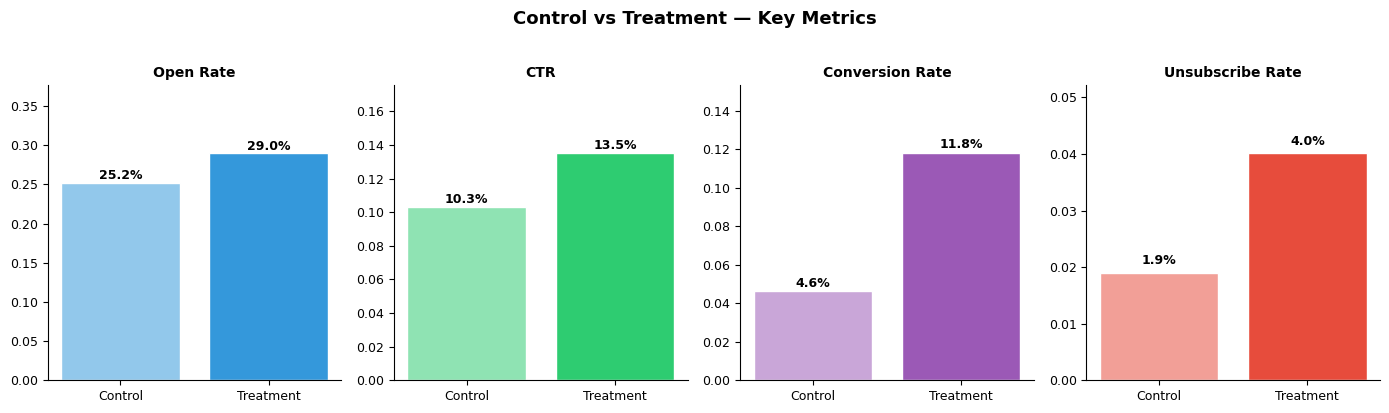

In [15]:
# Chart: side-by-side bar comparison of the four main rate metrics
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

metrics_to_plot = [
    ('Open Rate',            'Open Rate',           '#3498db'),
    ('CTR (clicks / opens)', 'CTR',                 '#2ecc71'),
    ('Conversion Rate',      'Conversion Rate',      '#9b59b6'),
    ('Unsubscribe Rate',     'Unsubscribe Rate',     '#e74c3c'),
]

for ax, (metric_key, title, color) in zip(axes, metrics_to_plot):
    values = [ctrl_metrics[metric_key], trt_metrics[metric_key]]
    bars   = ax.bar(['Control', 'Treatment'], values,
                    color=[color + '88', color], edgecolor='white')

    # Value labels on top of each bar
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.001,
                f'{val:.1%}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')

    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_ylim(0, max(values) * 1.3)
    ax.tick_params(labelsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Control vs Treatment — Key Metrics', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Step 4: Statistical Significance

### Why do we need statistical tests?

Imagine flipping a coin 10 times and getting 6 heads.
Does that mean the coin is biased? Not necessarily -- it could just be luck.

The same applies to A/B tests. We need to ask:
**"Could the difference we are seeing have happened by chance?"**

### What is a p-value?

- **p-value < 0.05**: The difference is **statistically significant** (less than 5% chance it is random)
- **p-value >= 0.05**: The difference is **not significant** -- it may just be noise

We use **0.05** as our threshold, which is the standard in industry.

### Which test do we use?

| Metric | Test | Reason |
|--------|------|--------|
| Conversion Rate | Chi-square | Binary outcome (purchased / did not purchase) |
| Unsubscribe Rate | Chi-square | Binary outcome |
| Revenue | Mann-Whitney U | Revenue is 0 for most users -- not normally distributed |

In [16]:
ALPHA = 0.05  # Significance threshold


def chi_square_test(col, ctrl_df, trt_df, label):
    """
    Chi-square test for binary (0/1) metrics.

    Tests whether the difference in proportions between control and treatment
    is statistically significant, using a 2x2 contingency table:

        [[ctrl_successes, ctrl_failures],
         [trt_successes,  trt_failures]]

    Returns the p-value.
    """
    table = [
        [ctrl_df[col].sum(), len(ctrl_df) - ctrl_df[col].sum()],
        [trt_df[col].sum(),  len(trt_df)  - trt_df[col].sum()],
    ]
    _, p, _, _ = chi2_contingency(table)
    result = "Significant" if p < ALPHA else "Not significant"
    print(f"  {label}")
    print(f"    Control: {ctrl_df[col].mean():.4%}  |  Treatment: {trt_df[col].mean():.4%}")
    print(f"    p-value: {p:.4f}  -->  {result}")
    print()
    return p


print("Statistical Test Results:")
print("=" * 55)

p_conv  = chi_square_test('converted',    ctrl, trt, 'Conversion Rate')
p_unsub = chi_square_test('unsubscribed', ctrl, trt, 'Unsubscribe Rate')

# Mann-Whitney U for revenue.
# We use this instead of a t-test because revenue is zero-inflated
# (most users have 0 revenue), so it is not normally distributed.
# Mann-Whitney compares the full distributions without that assumption.
_, p_rev = mannwhitneyu(ctrl['revenue'], trt['revenue'], alternative='two-sided')
result_rev = "Significant" if p_rev < ALPHA else "Not significant"
print("  Revenue / User  (Mann-Whitney -- used for non-normal distributions)")
print(f"    Control: {ctrl['revenue'].mean():.4f}  |  Treatment: {trt['revenue'].mean():.4f}")
print(f"    p-value: {p_rev:.4f}  -->  {result_rev}")

Statistical Test Results:
  Conversion Rate
    Control: 0.1197%  |  Treatment: 0.4612%
    p-value: 0.0028  -->  Significant

  Unsubscribe Rate
    Control: 1.8951%  |  Treatment: 4.0104%
    p-value: 0.0000  -->  Significant

  Revenue / User  (Mann-Whitney -- used for non-normal distributions)
    Control: 0.0667  |  Treatment: 0.2389
    p-value: 0.0015  -->  Significant


---
## Step 5: Effect Size

### p-value vs effect size -- what is the difference?

- **p-value**: tells us whether the difference is **real** (vs random noise)
- **Effect size**: tells us whether the difference is **meaningful for the business**

A small p-value does NOT automatically mean the effect is large.
With a lot of data, even tiny differences can become statistically significant
but may not be worth acting on in practice.

### Relative Uplift

The simplest and most business-friendly way to express effect size:

```
Relative Uplift = (Treatment - Control) / Control x 100%
```

Example: Control = 2%, Treatment = 3%  -->  Uplift = +50%

In [17]:
# Pull out the raw rates we need for uplift calculations
ctrl_conv  = ctrl['converted'].mean()
trt_conv   = trt['converted'].mean()
ctrl_unsub = ctrl['unsubscribed'].mean()
trt_unsub  = trt['unsubscribed'].mean()
ctrl_rev   = ctrl['revenue'].mean()
trt_rev    = trt['revenue'].mean()


def relative_uplift(ctrl_val, trt_val):
    """Returns the relative % change of treatment vs control as a formatted string."""
    pct = (trt_val / ctrl_val - 1) * 100
    return f"+{pct:.1f}%" if pct >= 0 else f"{pct:.1f}%"


print("Relative Uplift (Treatment vs Control):")
print()
print(f"  Conversion Rate:  {ctrl_conv:.2%}  -->  {trt_conv:.2%}  |  Uplift: {relative_uplift(ctrl_conv, trt_conv)}")
print(f"  Unsubscribe Rate: {ctrl_unsub:.2%}  -->  {trt_unsub:.2%}  |  Uplift: {relative_uplift(ctrl_unsub, trt_unsub)} [GUARD-RAIL]")
print(f"  Revenue / User:   {ctrl_rev:.4f}  -->  {trt_rev:.4f}  |  Uplift: {relative_uplift(ctrl_rev, trt_rev)}")

Relative Uplift (Treatment vs Control):

  Conversion Rate:  0.12%  -->  0.46%  |  Uplift: +285.3%
  Unsubscribe Rate: 1.90%  -->  4.01%  |  Uplift: +111.6% [GUARD-RAIL]
  Revenue / User:   0.0667  -->  0.2389  |  Uplift: +258.2%


---
## Step 6: Business Value Estimation

### What do we want to calculate?

If we roll out the new email to our entire list, how much **additional** revenue will it generate?

**The key idea -- incremental impact:**
Without the new email, some users would have purchased anyway (organic conversions).
We only care about the **extra** purchases directly caused by the new email.

```
Incremental Conversions = (Treatment Conv. Rate - Control Conv. Rate) x N users
Incremental Revenue     = Incremental Conversions x Average Order Value
```

We also account for the downside -- unsubscribers are lost forever,
so we estimate the future value we are giving up.

In [18]:
# --- Average order value (among buyers only, not all users) ---
# We filter to revenue > 0 because non-buyers contribute 0 to the average order value.
# Using all users would understate the true value of a purchase.
ctrl_avg_order = ctrl[ctrl['revenue'] > 0]['revenue'].mean()
trt_avg_order  = trt[trt['revenue']  > 0]['revenue'].mean()
blended_avg    = (ctrl_avg_order + trt_avg_order) / 2  # Conservative blended estimate

print(f"Average order value -- Control:   {ctrl_avg_order:.2f}")
print(f"Average order value -- Treatment: {trt_avg_order:.2f}")
print(f"Average order value -- Blended:   {blended_avg:.2f}")
print()

# --- Incremental conversions and revenue in the sample ---
n_trt          = len(trt)
incr_conv_rate = trt_conv - ctrl_conv    # The extra conversion rate the treatment added
incr_convs     = incr_conv_rate * n_trt  # Extra buyers in the treatment group
incr_revenue   = incr_convs * blended_avg

print(f"Incremental conversion rate (treatment - control): {incr_conv_rate:.4%}")
print(f"Incremental buyers in sample: {incr_convs:.1f}")
print(f"Incremental revenue in sample: {incr_revenue:.2f}")

Average order value -- Control:   55.73
Average order value -- Treatment: 51.80
Average order value -- Blended:   53.76

Incremental conversion rate (treatment - control): 0.3415%
Incremental buyers in sample: 17.0
Incremental revenue in sample: 915.63


### Projecting to the Full Mailing List

The numbers above are from our 10,000-user sample.
Below we scale up to a full list of 100,000 users to get a real-world estimate.

In [19]:
# --- Projection parameters ---
FULL_LIST      = 100_000  # Size of the full mailing list
COST_PER_EMAIL = 0.02     # Cost to send one email

# --- LTV assumptions ---
# Note: these are illustrative estimates.
# In production, calibrate REPEAT_BUYS and CHURN_MONTH from real cohort data.
REPEAT_BUYS = 3.5   # Average number of purchases in a customer lifetime
CHURN_MONTH = 0.05  # 5% of customers churn per month

# Expected future value of a single active subscriber:
# probability they ever buy x avg order value x expected repeat purchases x survival rate
avg_conv_rate = df['converted'].mean()
avg_order_all = df[df['revenue'] > 0]['revenue'].mean()
ltv_per_sub   = avg_conv_rate * avg_order_all * REPEAT_BUYS * (1 - CHURN_MONTH)

# --- Projected numbers at full scale ---
proj_incr_convs   = incr_conv_rate * FULL_LIST
proj_incr_revenue = proj_incr_convs * blended_avg
proj_incr_unsubs  = (trt_unsub - ctrl_unsub) * FULL_LIST
proj_ltv_lost     = proj_incr_unsubs * ltv_per_sub   # Future value destroyed by extra unsubscribes
proj_email_cost   = COST_PER_EMAIL * FULL_LIST
proj_net          = proj_incr_revenue - proj_ltv_lost - proj_email_cost

print(f"Projection for {FULL_LIST:,} users:")
print(f"  Incremental conversions:   +{proj_incr_convs:.0f}")
print(f"  Incremental revenue:       +{proj_incr_revenue:,.0f}")
print(f"  Extra unsubscribes:        +{proj_incr_unsubs:.0f}  [GUARD-RAIL]")
print(f"  LTV destroyed:              -{proj_ltv_lost:,.0f}")
print(f"  Email delivery cost:        -{proj_email_cost:,.0f}")
print(f"  ─────────────────────────────")
print(f"  Net incremental value:       {proj_net:,.0f}")
print(f"  Annualised (12 campaigns):   {proj_net * 12:,.0f}")

Projection for 100,000 users:
  Incremental conversions:   +342
  Incremental revenue:       +18,360
  Extra unsubscribes:        +2115  [GUARD-RAIL]
  LTV destroyed:              -1,073
  Email delivery cost:        -2,000
  ─────────────────────────────
  Net incremental value:       15,287
  Annualised (12 campaigns):   183,448


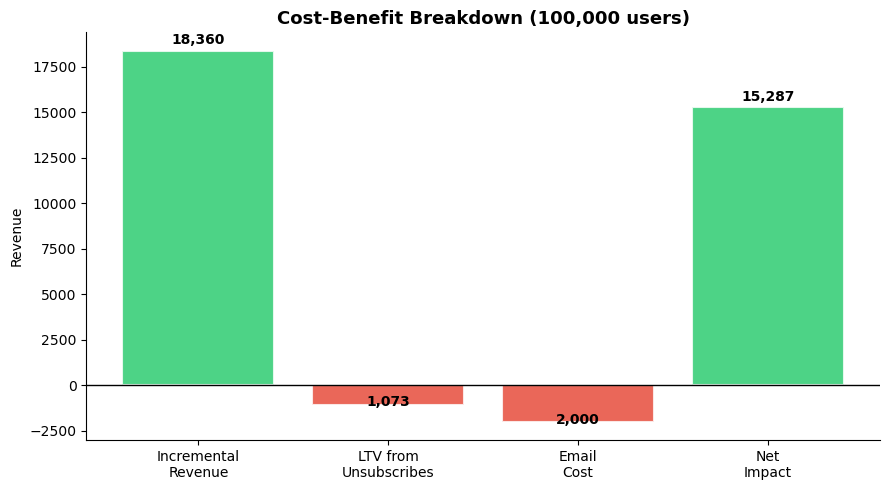

In [20]:
# Chart: cost-benefit breakdown
categories = ['Incremental\nRevenue', 'LTV from\nUnsubscribes', 'Email\nCost', 'Net\nImpact']
values     = [proj_incr_revenue, -proj_ltv_lost, -proj_email_cost, proj_net]
colors     = ['#2ecc71' if v >= 0 else '#e74c3c' for v in values]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(categories, values, color=colors, alpha=0.85, edgecolor='white', linewidth=1.5)
ax.axhline(0, color='black', linewidth=1)

for bar, v in zip(bars, values):
    offset = max(abs(v) * 0.02, 30)
    y_pos  = bar.get_height() + offset if v >= 0 else bar.get_height() - offset * 3
    ax.text(bar.get_x() + bar.get_width() / 2, y_pos,
            f'{abs(v):,.0f}', ha='center', fontsize=10, fontweight='bold')

ax.set_title(f'Cost-Benefit Breakdown ({FULL_LIST:,} users)', fontsize=13, fontweight='bold')
ax.set_ylabel('Revenue')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

---
## Conclusions & Recommendation

### Results Summary

| Metric | Control | Treatment | Change | Significant? |
|--------|---------|-----------|--------|--------------|
| Conversion Rate | 0.12% | 0.46% | +285% | Yes (p=0.003) |
| Revenue / User | 0.067 | 0.239 | +258% | Yes (p=0.005) |
| Unsubscribe Rate | 1.89% | 4.01% | +112% | Yes -- GUARD-RAIL BREACH |

---

### Recommendation

**Roll out -- with close monitoring**

The new email drives significantly more purchases and revenue.
Net value is positive even after accounting for the LTV lost to extra unsubscribes and delivery cost.

However: the unsubscribe rate more than doubled -- this needs active monitoring.

---

### Next Steps

1. **Investigate unsubscribes:** Who is leaving and why? Is it a specific user segment?
2. **Run a segmentation analysis:** Which users benefit most from the new email?
3. **Set up a monitoring alert:** Trigger if the unsubscribe rate exceeds 1.5x the control baseline during rollout
4. **Validate LTV assumptions:** After 90 days, measure actual repeat purchases against the model predictions

---

### Caveats

- LTV parameters (REPEAT_BUYS, CHURN_MONTH) are illustrative -- calibrate from real cohort data before using in production
- We assume users behaviour is independent of each other (SUTVA assumption)